<a href="https://colab.research.google.com/github/simply-logical/mlbook_ii_notebooks/blob/master/HelloSimpleAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
! pip install datasets pyarrow mlcroissant --quiet

In [5]:
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

import re
import os
import tarfile
import logging
import requests
from collections import Counter
import warnings
from absl import logging as absl_logging


import pandas as pd
import seaborn as sns
from mlcroissant import Dataset

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

import ipywidgets as widgets
from IPython.display import display, clear_output

In [6]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
class DataSource(ABC):
  @abstractmethod
  def load_data(self) -> pd.DataFrame:
    pass

In [8]:
class HelloSimpleAIDataset(DataSource):

  def __init__(self, source="wiki_csai"):
    self.url = "https://huggingface.co/api/datasets/Hello-SimpleAI/HC3/croissant"
    self.source = source

  def load_data(self) -> pd.DataFrame:

    ds = Dataset(jsonld=self.url)
    records_iterator = ds.records(self.source)

    data = []
    print(f"Processing Hello-SimpleAI - {self.source}")
    data = [item for item in records_iterator]

    print(f"Done.Total records: {len(data)}")
    return pd.DataFrame(data)

In [9]:
class DataCleaner(ABC):
  @abstractmethod
  def clean_data(self, data: pd.DataFrame) -> pd.DataFrame:
    pass

In [10]:
class HelloSimpleAIDataCleaner(DataCleaner):
  def __init__(self, source="wiki_csai"):
    self.source = source

  def _clean_text(self, raw_text):
      text = re.sub(r"^\[?b['\"]|['\"]\]?$", "", raw_text)

      text = re.sub(r'\[[^\]]+\]', '', text)

      text = re.sub(r'\b(e\.g\.)', 'eg', text, flags=re.IGNORECASE)

      text = re.sub(r'\b(i\.e\.)', 'ie', text, flags=re.IGNORECASE)

      text = re.sub(r'\{\\displaystyle .*?\}', '', text)

      text = re.sub(r'\\x[0-9a-fA-F]{2}', '', text)

      text = re.sub(r'(\\n)+', ' ', text)

      text = re.sub(r'\\', '', text)

      text = re.sub(r"\s+", " ", text).strip()
      text = text.lower()

      return text

  def clean_data(self, data: pd.DataFrame) -> pd.DataFrame:

    for column in data.columns:
      data[column] = data[column].apply(lambda text: self._clean_text(str(text)))

    return data

In [11]:
class DataProcessor(ABC):
  @abstractmethod
  def process_dataframe(self, data: pd.DataFrame) -> pd.DataFrame:
    pass

In [12]:
class HelloSimpleAIDataProcessor(DataProcessor):
  def __init__(self, source="wiki_csai"):
    self.source = source

  def _remove_punctuation(self, text: str) -> str:
    return re.sub(r'[^\w\s]', '', text)

  def process_dataframe(self, df: pd.DataFrame, text_column: str) -> pd.DataFrame:
    print(f'Processing column: {text_column}')

    df['sentence_list'] = df[text_column].apply(sent_tokenize)

    df_sentences = df.explode('sentence_list').reset_index(drop=True)
    df_sentences = df_sentences.rename(columns={'sentence_list': 'sentence'})

    df_sentences = df_sentences[df_sentences['sentence'].str.strip().astype(bool)]

    df_sentences = df_sentences.dropna(subset=['sentence'])

    df_sentences['tokens'] = df_sentences['sentence'].astype(str).apply(self._remove_punctuation).apply(word_tokenize)
    df_sentences['word_count'] = df_sentences['tokens'].apply(len)

    df_sentences['avg_word_len'] = df_sentences['tokens'].apply(
            lambda words: sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    )

    df_sentences['char_count'] = df_sentences['sentence'].apply(len)

    return df_sentences

In [13]:
class HelloSimpleAIDataVisualizer():
    def __init__(self, palette: list=["#3498db", "#e67e22", "#9b59b6"], aplha: float=0.5):
        self.palette = palette
        self.alpha = aplha

    def plot_bar_chart(self, df: pd.DataFrame, title: str):
      plt.figure(figsize=(15, 6))
      ax = sns.barplot(data=df, palette=self.palette, alpha=self.alpha)
      for container in ax.containers:
          ax.bar_label(container, fmt='%.2f', padding=3)

      plt.title(title)
      plt.grid(True, axis='y', linestyle='--', alpha=0.7)

      sns.despine()

      plt.show()
      plt.close()

    def plot_histogram(self, df:  pd.DataFrame, title: str):


      for column, color in zip(df.columns, self.palette):

        plt.figure(figsize=(14.625,6))

        sns.histplot(
            df[column],
            kde=False,
            color=color,
            label=column,
            alpha=self.alpha,
            edgecolor="white",
            shrink=0.8,
            linewidth=0.25
        )

        plt.title(title)
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.legend()

        sns.despine()
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        plt.close()


        plt.show()
        plt.close()

    def plot_scatter_plot(self,
                          df1: pd.DataFrame,
                          df2: pd.DataFrame,
                          title: str,
                          label1: str,
                          label2: str,
                          column1: str='avg_word_len',
                          column2: str='char_count'
                          ):
        plt.figure(figsize=(12.165, 6))


        sns.scatterplot(
            data=df1[[column1, column2]],
            x=column2,
            y=column1,
            label=label1,
            alpha=0.7,
            edgecolor=None,
            color=self.palette[0]
        )


        sns.scatterplot(
            data=df2[[column1, column2]],
            x=column2,
            y=column1,
            label=label2,
            alpha=0.3,
            edgecolor=None,
            color=self.palette[1]
        )

        plt.grid(axis='y', alpha=0.3)
        plt.title(title, fontsize=16, pad=20)
        plt.xlabel("Sentence Length", fontsize=12)
        plt.ylabel("Average Word Length", fontsize=12)


        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        sns.despine()
        plt.tight_layout()
        plt.show()

    def plot_boxplot(self, df: pd.DataFrame,  title: str='Word Count'):

        plt.figure(figsize=(14.2, 6))
        sns.boxplot(df, palette=self.palette, boxprops=dict(alpha=self.alpha), orient='v', )
        sns.despine()

        plt.title(title, fontsize=16, pad=20)
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.xlabel("Language", fontsize=12)
        plt.ylabel(title, fontsize=12)

        plt.show()

    def plot_most_frequent_words(self, df: pd.DataFrame, title:str, top_n: int=10):

        plt.figure(figsize=(12.165, 6))

        ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])
        for container in ax.containers:
          ax.bar_label(container, fmt='%.3f', padding=3)

        plt.title(title, fontsize=18, pad=20)
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        sns.despine()
        plt.xlabel('Words', fontsize=14)
        plt.ylabel('Frequency', fontsize=14)

        plt.tight_layout()
        plt.show()



In [14]:
def most_frequent_words(df: pd.DataFrame, use_stop_words: bool=True, top_n: int=10):

    all_words = df['tokens'].explode()
    all_words = all_words.str.lower().dropna()

    if not use_stop_words:
      stop_words = set(nltk.corpus.stopwords.words('english'))
      all_words = all_words[~all_words.isin(stop_words)]

    word_counts = Counter(all_words)

    return pd.DataFrame(list(word_counts.most_common(top_n)), columns=['words', 'count'])

In [15]:
class Classification(ABC):
  @abstractmethod
  def run_classification(self):
    pass

In [16]:
import numpy as np

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

class HelloSimpleAIClassification(Classification):
    def __init__(self, df1: pd.DataFrame, df2: pd.DataFrame, vocab_size: int, source: str="wiki_csai" ):
      self.source = source
      self.df_human = df1
      self.df_gpt = df2
      self.vocab_size = vocab_size
      self.vocab = self._vocab_to_dict(self._get_one_hot_vocab())
      self.embeddings = self._generate_one_hot_embeddings()
      self.tf_idf_vector = self._generate_tf_idf_vector()
      self.target = self._generate_target()
      self.model = LogisticRegression(max_iter=1000)

    def _most_frequent_words(self, df: pd.DataFrame, use_stop_words: bool=True, top_n: int=10):

      all_words = df['tokens'].explode()
      all_words = all_words.str.lower().dropna()

      if not use_stop_words:
        stop_words = set(nltk.corpus.stopwords.words('english'))
        all_words = all_words[~all_words.isin(stop_words)]

      word_counts = Counter(all_words)

      return pd.DataFrame(list(word_counts.most_common(top_n)), columns=['words', 'count'])

    def _get_one_hot_vocab(self):
      size = self.vocab_size*2
      top_words_human = self._most_frequent_words(self.df_human, use_stop_words=False, top_n=size)
      top_words_gpt = self._most_frequent_words(self.df_gpt, use_stop_words=False, top_n=size)

      union = pd.Series(np.union1d(top_words_human['words'], top_words_gpt['words']))
      intersection = pd.Series(np.intersect1d(top_words_human['words'], top_words_gpt['words']))

      abs_dif = union[~union.isin(intersection)]

      if abs_dif.size > self.vocab_size:
        abs_dif = abs_dif[:self.vocab_size]

      if abs_dif.size < self.vocab_size:
        complement = np.random.choice(intersection, self.vocab_size - abs_dif.size, replace=False)
        abs_dif = np.concatenate((abs_dif, complement))

      return list(abs_dif)

    def _vocab_to_dict(self, vocab: list):
      vocab_dict = {}
      for i, word in enumerate(vocab):
        vocab_dict[word] = i
      return vocab_dict

    def _generate_one_hot_embeddings(self):
      df = pd.concat([self.df_human, self.df_gpt])
      one_hot_embeddings = np.zeros((len(df), self.vocab_size))

      for i, tokens in enumerate(df['tokens']):
        for token in tokens:
          if token in self.vocab:
            one_hot_embeddings[i, self.vocab[token]] = 1

      return one_hot_embeddings

    def _generate_target(self):
      return np.concatenate((np.zeros(len(self.df_human)), np.ones(len(self.df_gpt))))

    def get_target(self):
      return self.target

    def get_one_hot_embeddings(self):
      return self.embeddings

    def get_vocab(self):
      return self.vocab

    def get_df(self):
      return pd.concat([self.df_human, self.df_gpt])

    def view_sentences_and_embeddings(self):
      concat_df = pd.concat([self.df_human, self.df_gpt])

      concat_df['embeddings'] = list(self.embeddings)

      return concat_df[['tokens', 'embeddings']]

    def _plot_score_graphics(self, word_relevance: pd.DataFrame,  title: str, top_n: int=10):

      plt.figure(figsize=(12.165, 6))
      plt.title(title, fontsize=18, pad=20)

      ax = sns.barplot(x=word_relevance['word'], y=word_relevance['coefficient'],  palette=["#3498db"])
      for container in ax.containers:
          ax.bar_label(container, fmt='%.2f', padding=3)

      plt.grid(True, axis='y', linestyle='--', alpha=0.7)

      sns.despine()

      plt.show()
      plt.close()

    def _plot_decision_boundaries(self, word_relevance: pd.DataFrame, inverted_vocab: dict, coefs: list, top_n: int):

      df_plot = pd.DataFrame({
        'word': [inverted_vocab[i] for i in range(len(coefs))],
        'coefficients': coefs,
        'abs_coef': np.abs(coefs)
      })

      df_plot = df_plot.sort_values(by='coefficients')

      plt.figure(figsize=(12.465, 6))

      y_jitter = np.random.normal(0, 0.1, size=len(df_plot))

      scatter = plt.scatter(
          df_plot['coefficients'],
          y_jitter,
          alpha=0.4,
          c=df_plot['coefficients'],
          cmap='coolwarm',
          s=df_plot['abs_coef'] * 500
      )


      top_gpt = df_plot.tail(top_n)
      for i, row in top_gpt.iterrows():
          plt.annotate(row['word'], (row['coefficients'], y_jitter[df_plot.index.get_loc(i)]),
                      xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

      top_human = df_plot.head(top_n)
      for i, row in top_human.iterrows():
          plt.annotate(row['word'], (row['coefficients'], y_jitter[df_plot.index.get_loc(i)]),
                      xytext=(-5, 5), textcoords='offset points', fontsize=12, fontweight='bold', ha='right')

      plt.axvline(0, color='black', linestyle='--', alpha=0.6)
      plt.title('Weight Distribution For Words', fontsize=16)
      plt.xlabel('Coefficient (Negative: Human | Positive: GPT)', fontsize=14)
      plt.yticks([])
      plt.gca().spines['left'].set_visible(False)
      plt.gca().spines['right'].set_visible(False)
      plt.gca().spines['top'].set_visible(False)

      plt.colorbar(scatter, label='Coefficient Intensity')
      plt.show()


    def _plot_logistic_curve(self):

      probs = self.model.predict_proba(self.embeddings)[:, 1]
      log_odds = self.model.decision_function(self.embeddings)

      df_curve = pd.DataFrame({
          'log_odds': log_odds,
          'probs': probs,
          'target': self.target
      }).sort_values(by='log_odds')

      plt.figure(figsize=(12.165, 6))

      plt.scatter(df_curve['log_odds'], df_curve['target'], alpha=0.3, c=df_curve['target'], cmap='coolwarm', label='Real data (0: Human, 1: GPT)')
      plt.plot(df_curve['log_odds'], df_curve['probs'], color='black', linewidth=2, label='Sigmoid curve')

      plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
      plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

      plt.title('Logistic Curve (Probs vs. Log-Odds)', fontsize=14)
      plt.xlabel('Linear Combination of Weights (Decision Function)', fontsize=12)
      plt.ylabel('Predicted Probabilities (GPT)', fontsize=12)
      plt.legend()
      plt.grid(True, alpha=0.3)
      plt.show()



    def _score_interpretation(self, top_n: int=10):

      inv_vocab = {v: k for k, v in self.vocab.items()}
      coefs = self.model.coef_[0]

      word_relevance = pd.DataFrame({
          'word': [inv_vocab[i] for i in range(len(coefs))],
          'coefficient': coefs
      })

      gpt_words = word_relevance.sort_values(by='coefficient', ascending=False).head(top_n)
      human_words = word_relevance.sort_values(by='coefficient', ascending=True).head(top_n)

      print(f"\n--- Top {top_n} words for GPT (Class 1) ---")
      print(gpt_words)

      self._plot_score_graphics(gpt_words, f"Top {top_n} words for GPT (Class 1)", top_n)

      print(f"\n--- Top {top_n} words for Humans (Class 0) ---")
      print(human_words)

      self._plot_score_graphics(human_words,  f"Top {top_n} words for Human (Class 0)", top_n)

      self._plot_decision_boundaries(word_relevance, inv_vocab, coefs, top_n)
      self._plot_logistic_curve()


    def run_classification(self):

      X_train, X_test, y_train, y_test = train_test_split(
          self.embeddings,
          self.target,
          test_size=0.2,
          random_state=42,
          shuffle=True,
          stratify=self.target
      )

      print('Training Logistic Regression...')
      self.model.fit(X_train, y_train)

      y_pred = self.model.predict(X_test)
      accuracy = accuracy_score(y_test, y_pred)
      print(f"Accuracy: {accuracy:.2%}")

      self._score_interpretation()

    def _generate_tf_idf_vector(self):

      df = pd.concat([self.df_gpt, self.df_human])

      tf_idf_vector = TfidfVectorizer()

      return tf_idf_vector.fit_transform(df['sentence'])


  -  [Metadata(HC3)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.
  -  [Metadata(HC3)] Property "https://schema.org/datePublished" is recommended, but does not exist.
  -  [Metadata(HC3)] Property "https://schema.org/version" is recommended, but does not exist.


Processing Hello-SimpleAI - wiki_csai


Done.Total records: 842
Processing column: wiki_csai/human_answers
Processing column: wiki_csai/chatgpt_answers


/tmp/ipykernel_4255/227513387.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, palette=self.palette, alpha=self.alpha)
/tmp/ipykernel_4255/227513387.py:8: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(data=df, palette=self.palette, alpha=self.alpha)


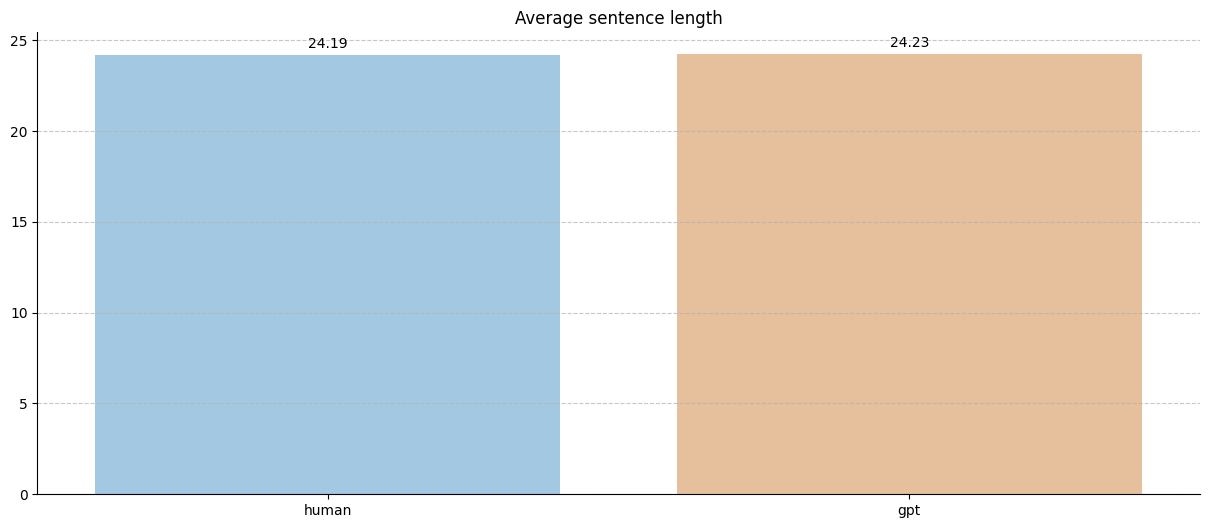

/tmp/ipykernel_4255/227513387.py:100: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(df, palette=self.palette, boxprops=dict(alpha=self.alpha), orient='v', )


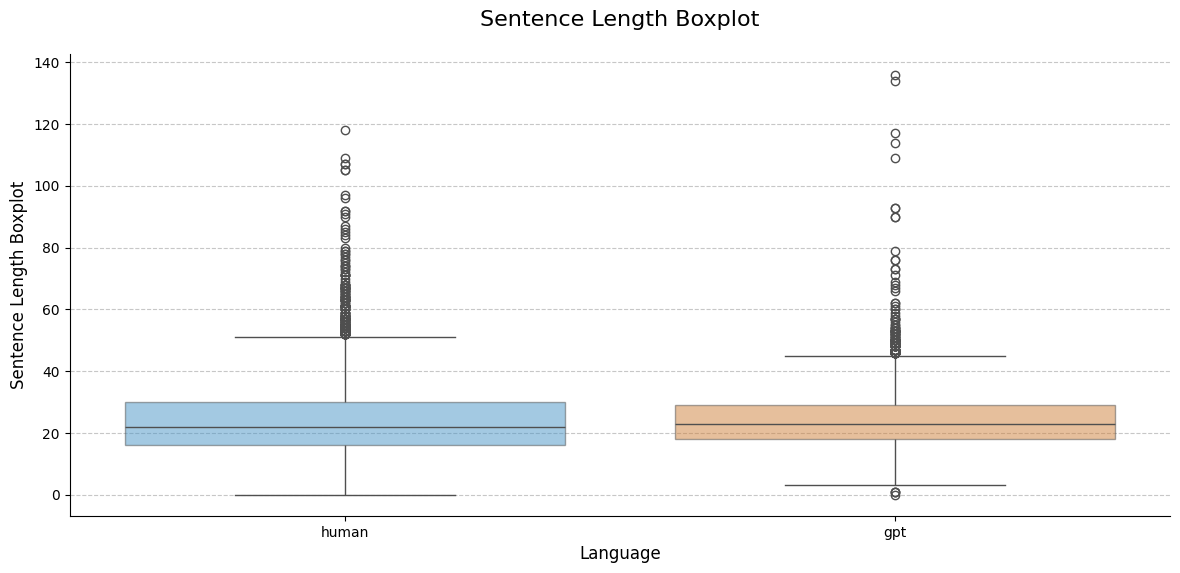

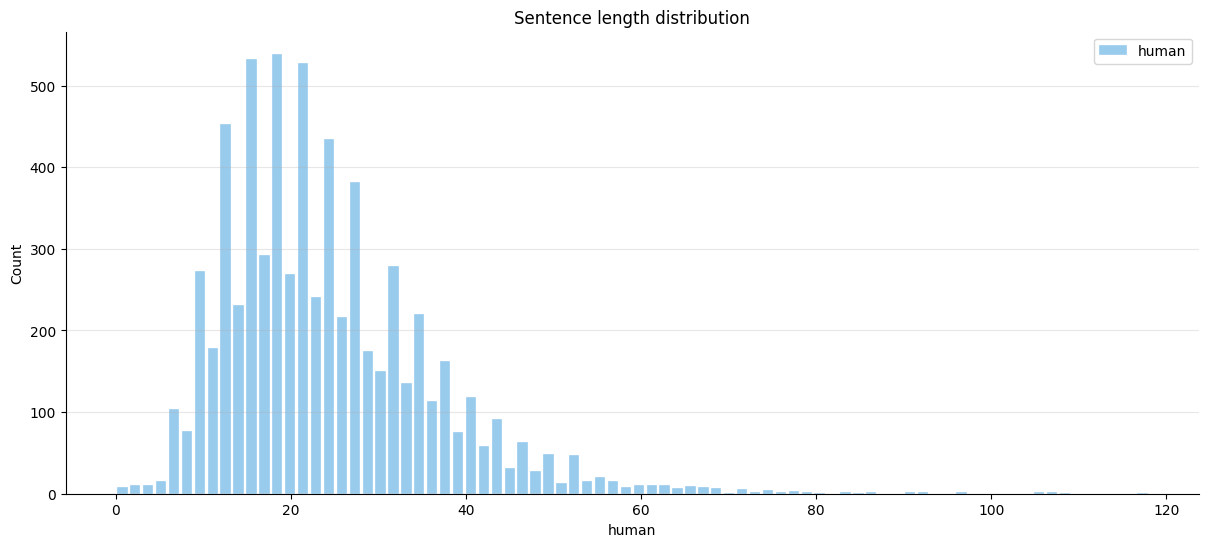

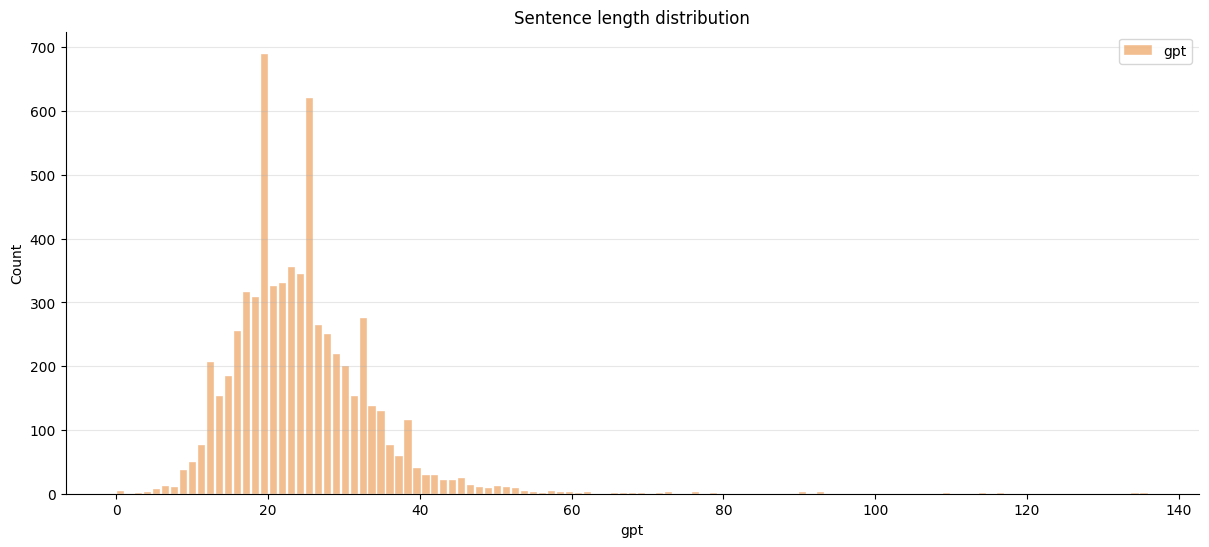

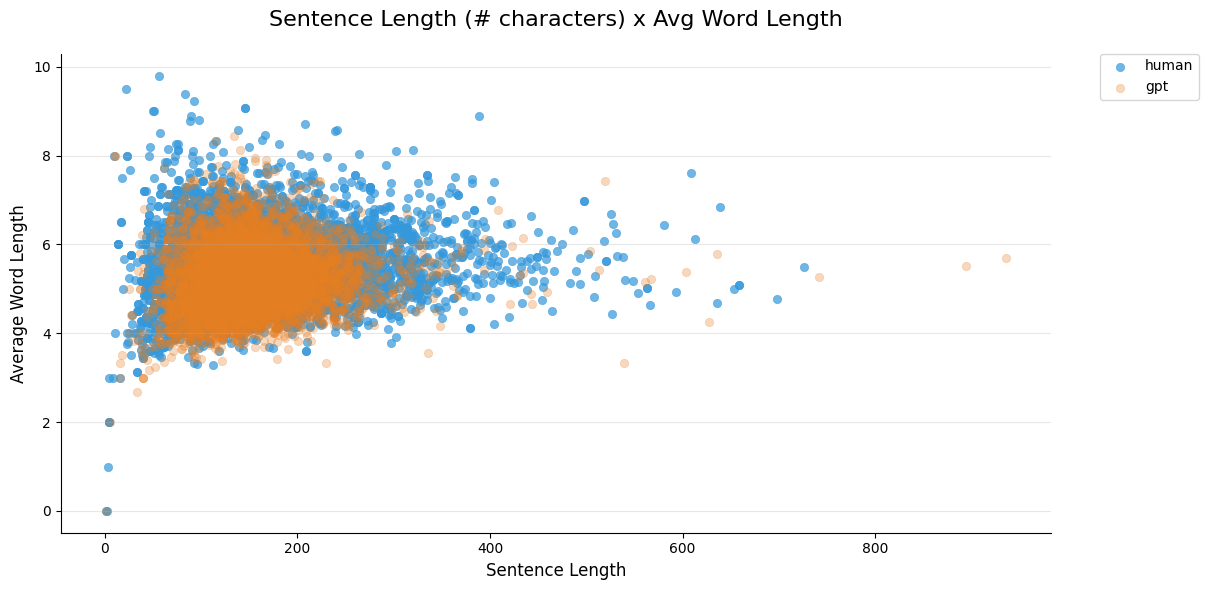

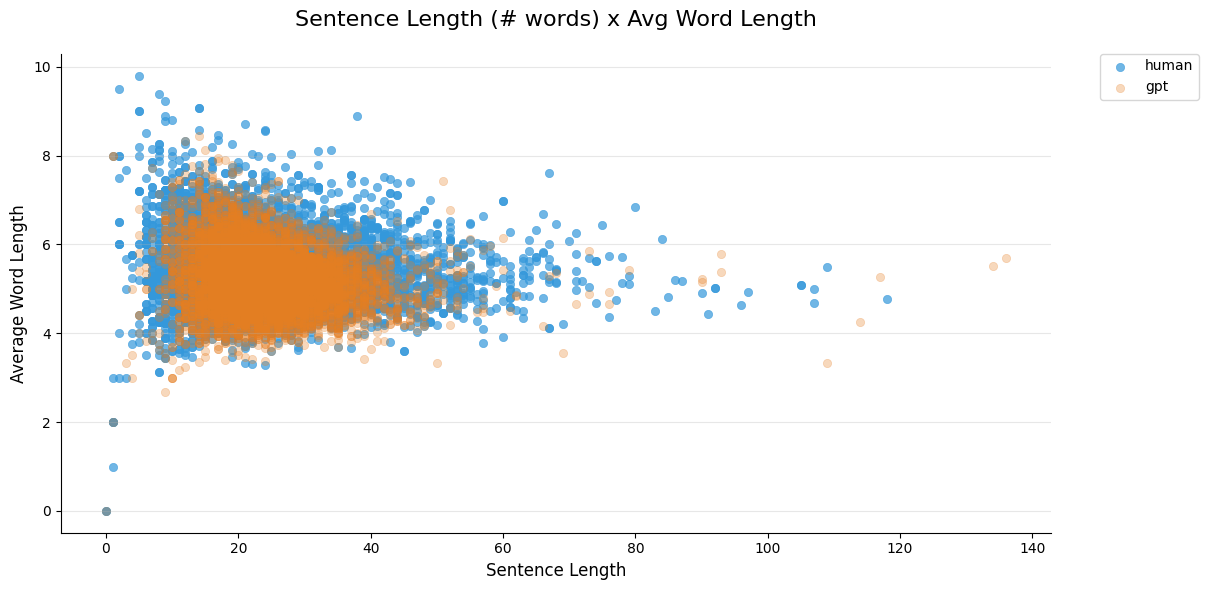

/tmp/ipykernel_4255/227513387.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])
/tmp/ipykernel_4255/227513387.py:114: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])


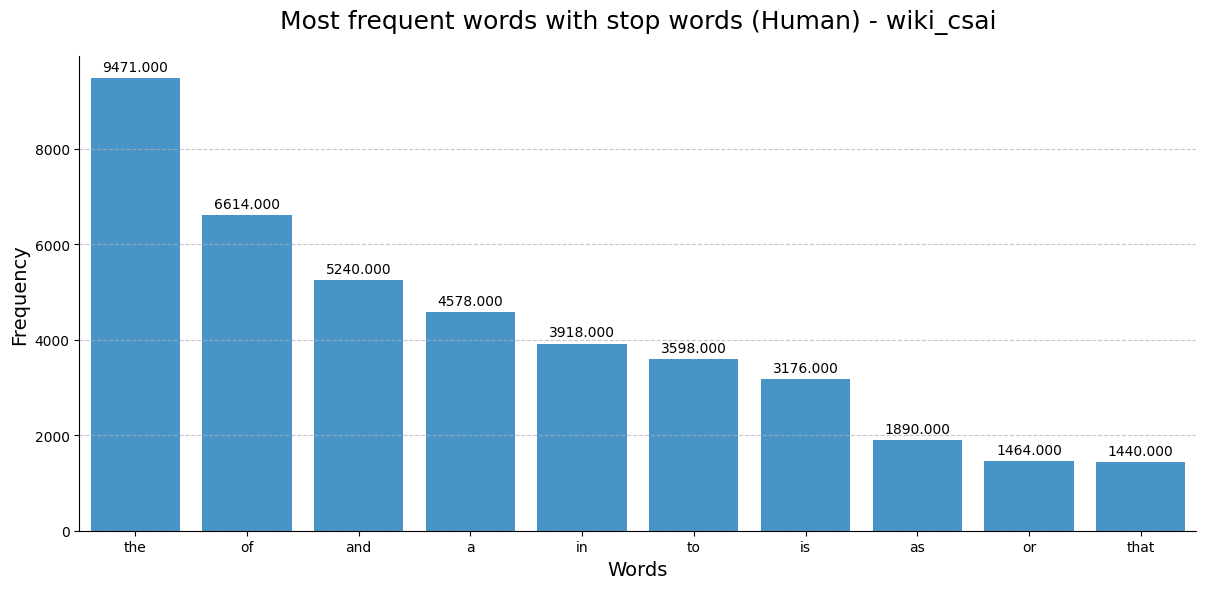

/tmp/ipykernel_4255/227513387.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])
/tmp/ipykernel_4255/227513387.py:114: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])


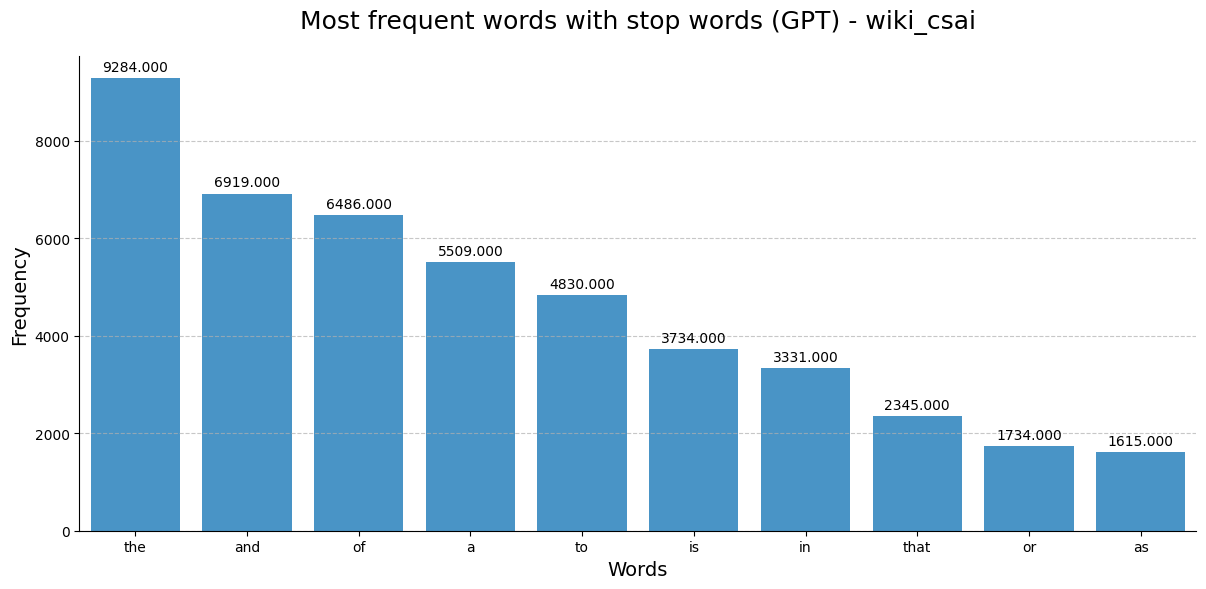

/tmp/ipykernel_4255/227513387.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])
/tmp/ipykernel_4255/227513387.py:114: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])


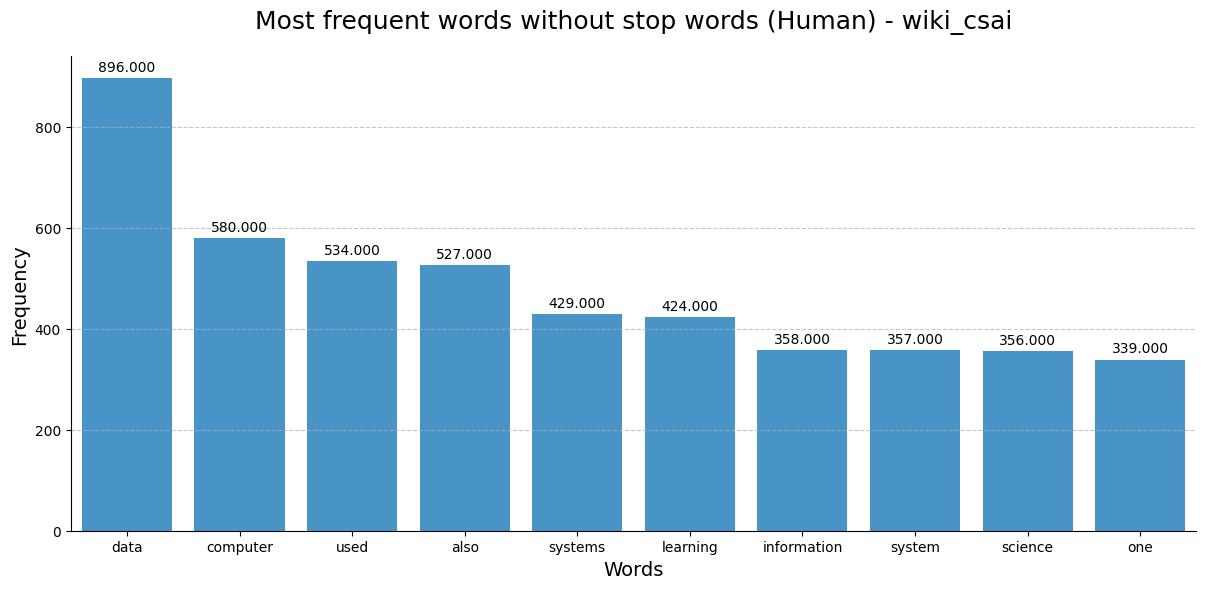

/tmp/ipykernel_4255/227513387.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])
/tmp/ipykernel_4255/227513387.py:114: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=df['words'], y=df['count'],  palette=["#3498db"])


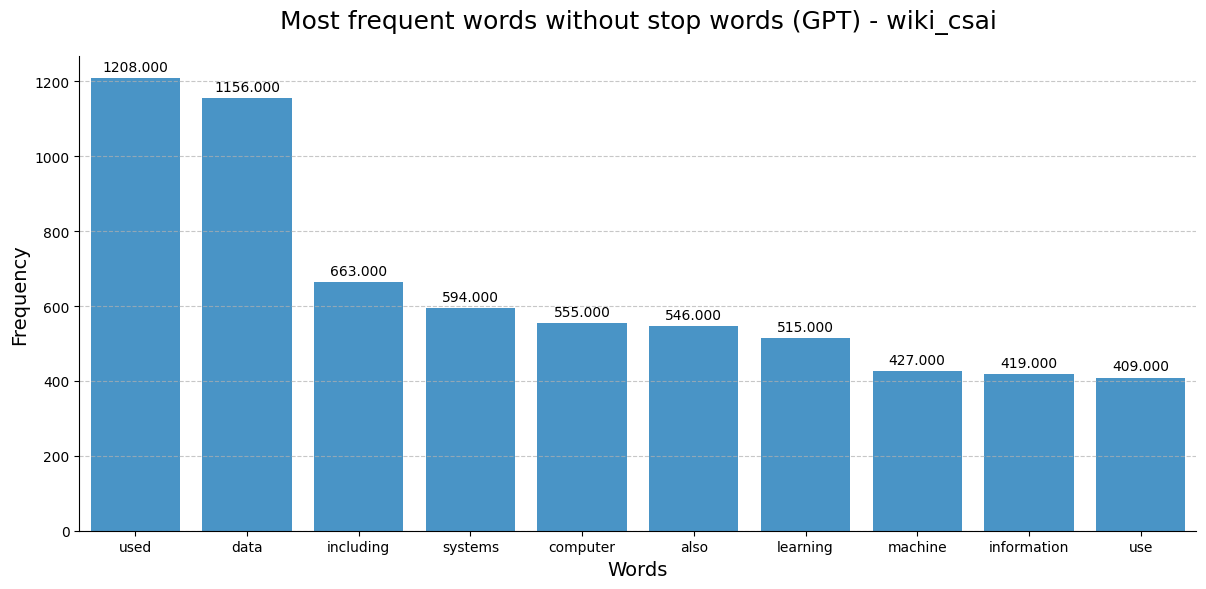

Training Logistic Regression...
Accuracy: 58.10%

--- Top 10 words for GPT (Class 1) ---
            word  coefficient
12      involves     1.795786
17         range     1.420424
14          make     1.162465
5      different     0.835132
1   applications     0.810472
4    development     0.703585
2          based     0.507123
8          field     0.433735
11         image     0.377830
19      software     0.069466


/tmp/ipykernel_4255/2100468409.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=word_relevance['word'], y=word_relevance['coefficient'],  palette=["#3498db"])
/tmp/ipykernel_4255/2100468409.py:97: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=word_relevance['word'], y=word_relevance['coefficient'],  palette=["#3498db"])


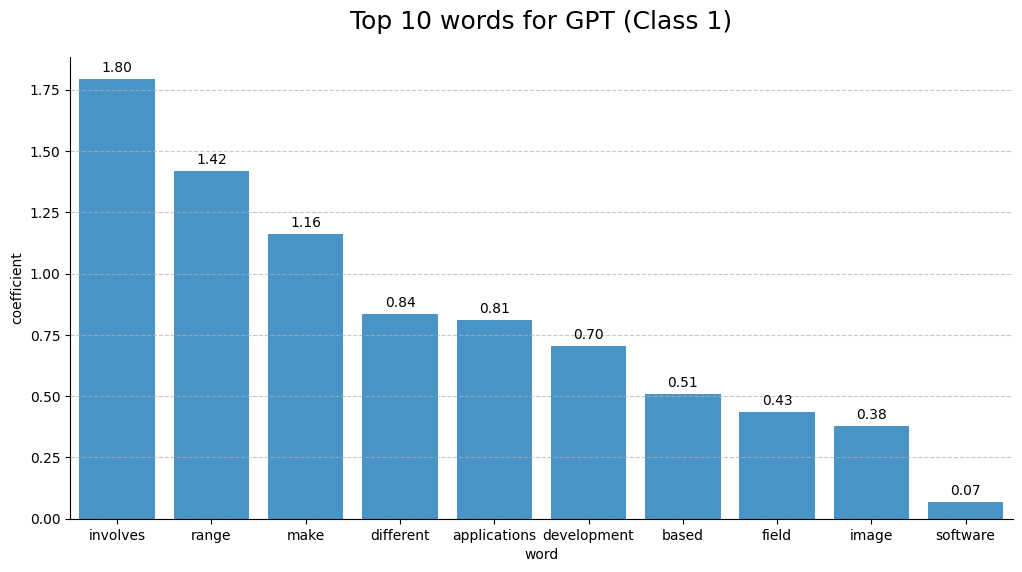


--- Top 10 words for Humans (Class 0) ---
            word  coefficient
6   displaystyle    -2.779937
9          first    -1.064463
3         called    -0.605133
0       analysis    -0.439867
13         logic    -0.431334
7    engineering    -0.425627
15       problem    -0.317909
10         human    -0.106562
18      research    -0.048006
16      problems     0.005565


/tmp/ipykernel_4255/2100468409.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=word_relevance['word'], y=word_relevance['coefficient'],  palette=["#3498db"])
/tmp/ipykernel_4255/2100468409.py:97: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=word_relevance['word'], y=word_relevance['coefficient'],  palette=["#3498db"])


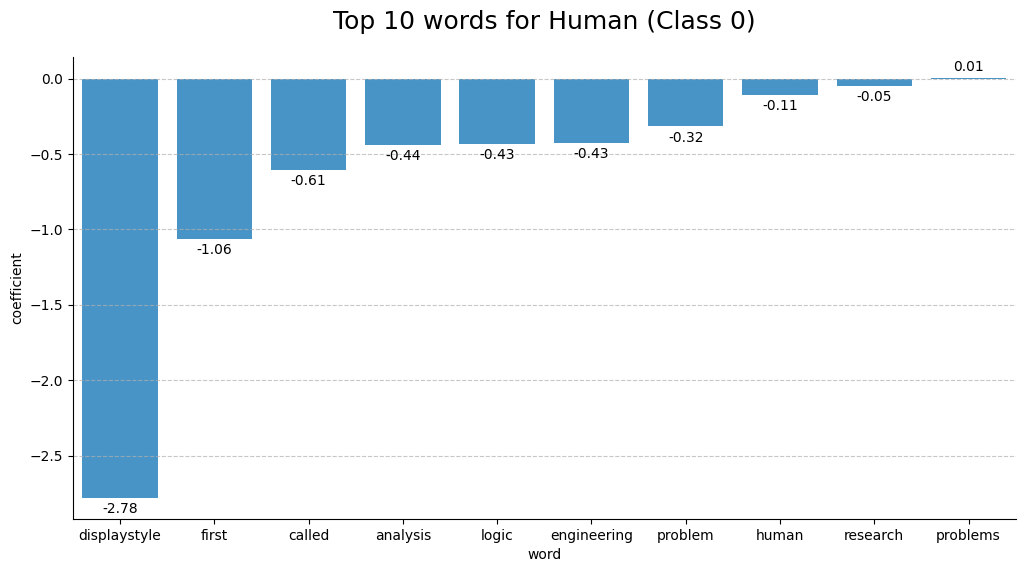

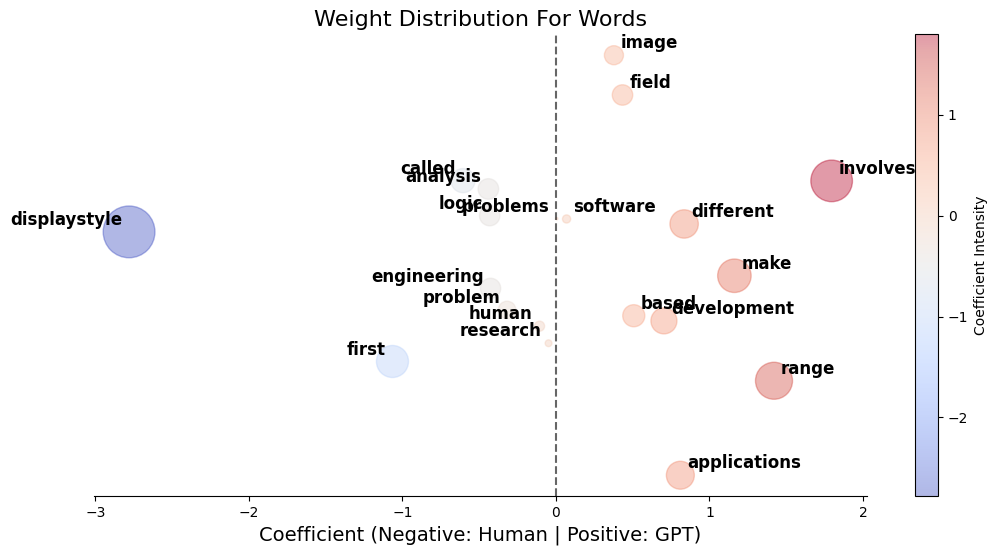

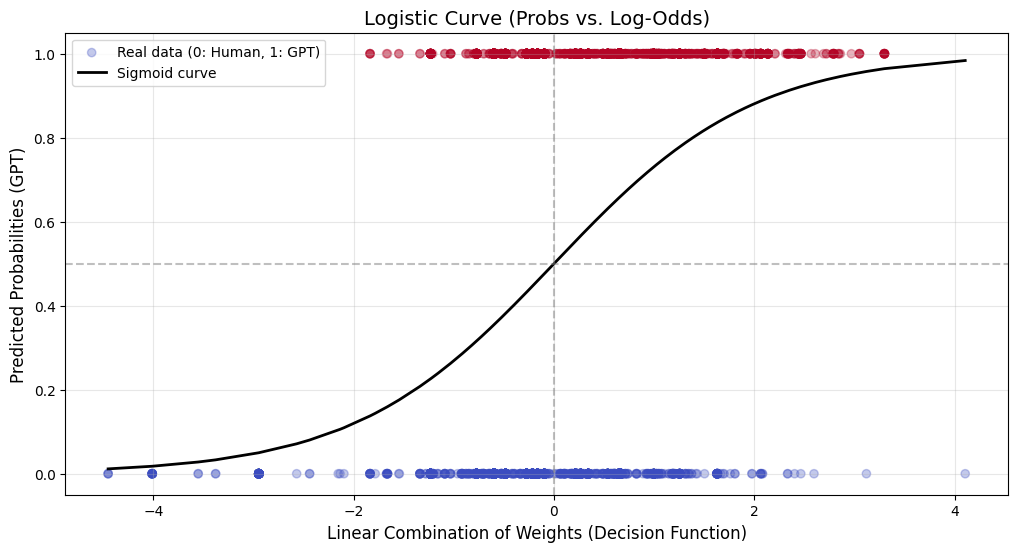

In [18]:
source = 'wiki_csai'

dataset = HelloSimpleAIDataset(source=source)
dataset = dataset.load_data()

data_cleaner = HelloSimpleAIDataCleaner()
cleaned_data = data_cleaner.clean_data(dataset)

data_processor = HelloSimpleAIDataProcessor(source=source)
processed_data_human = data_processor.process_dataframe(cleaned_data, f'{source}/human_answers')
processed_data_gpt = data_processor.process_dataframe(cleaned_data, f'{source}/chatgpt_answers')

sentence_len = pd.DataFrame({
  'human': processed_data_human['word_count'],
  'gpt': processed_data_gpt['word_count']
})

data_visualizer = HelloSimpleAIDataVisualizer()
data_visualizer.plot_bar_chart(df=sentence_len.mean(), title="Average sentence length")

data_visualizer.plot_boxplot(sentence_len, title="Sentence Length Boxplot")
data_visualizer.plot_histogram(sentence_len, f"Sentence length distribution")

data_visualizer.plot_scatter_plot(processed_data_human, processed_data_gpt, title=f"Sentence Length (# characters) x Avg Word Length", label1='human', label2='gpt')
data_visualizer.plot_scatter_plot(processed_data_human, processed_data_gpt, title=f"Sentence Length (# words) x Avg Word Length", label1='human', label2='gpt', column1='avg_word_len', column2='word_count')

data_visualizer.plot_most_frequent_words(most_frequent_words(processed_data_human, use_stop_words=True), f"Most frequent words with stop words (Human) - {source}")
data_visualizer.plot_most_frequent_words(most_frequent_words(processed_data_gpt, use_stop_words=True), f"Most frequent words with stop words (GPT) - {source}")

data_visualizer.plot_most_frequent_words(most_frequent_words(processed_data_human, use_stop_words=False), f"Most frequent words without stop words (Human) - {source}")
data_visualizer.plot_most_frequent_words(most_frequent_words(processed_data_gpt, use_stop_words=False), f"Most frequent words without stop words (GPT) - {source}")

classification = HelloSimpleAIClassification(processed_data_human, processed_data_gpt, vocab_size=20)
classification.run_classification()